----------------------
#### Aim : how to do a sup classification using Keras
---------------------------

In [ ]:
#!pip install tensorflow

In [1]:
import pandas as pd
import numpy  as np

from keras.utils import plot_model

In [2]:
location = r'https://github.com/gridflowai/gridflowAI-datasets-icons/raw/master/AI-DATASETS/01-MISC/pima.txt'

In [3]:
data = pd.read_csv(location)

In [4]:
data.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
633,1,128,82,17,183,27.5,0.115,22,0
156,2,99,52,15,94,24.6,0.637,21,0
218,5,85,74,22,0,29.0,1.224,32,1
573,2,98,60,17,120,34.7,0.198,22,0
599,1,109,38,18,120,23.1,0.407,26,0


In [5]:
data.shape

(768, 9)

In [6]:
39 * 16

624

In [7]:
768 * .8

614.4000000000001

__Input__ Variables (X):

    Number of times pregnant
    Plasma glucose concentration a 2 hours in an oral glucose tolerance test
    Diastolic blood pressure (mm Hg)
    Triceps skin fold thickness (mm)
    2-Hour serum insulin (mu U/ml)
    Body mass index (weight in kg/(height in m)^2)
    Diabetes pedigree function
    Age (years)

__Output__ Variables (y):

    Class variable (0 or 1)

In [8]:
# split into input (X) and output (y) variables
X = data.iloc[:, 0:8]
y = data.iloc[:, 8]

In [9]:
X.shape

(768, 8)

#### Scaling

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_val_scaled = scaler.fit_transform(X)

#### build the machine learning model

In [11]:
from keras.models import Sequential # 1
from keras.layers import Dense      # 2

In [13]:
# define the keras model
model = Sequential()

model.add(Dense(units=64, input_dim=8, activation='relu',    name='Data-Input-Layer'))
model.add(Dense(units=32,              activation='relu',    name='Hidden-Layer-1'))
# model.add(Dense(units=256,              activation='relu',    name='Hidden-Layer-2'))
# model.add(Dense(units=128,              activation='relu',    name='Hidden-Layer-3'))
# model.add(Dense(units=64,               activation='relu',    name='Hidden-Layer-4'))
# model.add(Dense(units=32,              activation='relu',    name='Hidden-Layer-5'))
# model.add(Dense(units=4,               activation='relu',    name='Hidden-Layer-6'))
model.add(Dense(units=1,                activation='sigmoid', name='Output-Layer'))   # why sigmoid?

| Optimizer name      | Description                                            |
| ------------------- | ------------------------------------------------------ |
| class Adadelta:     | Optimizer that implements the Adadelta algorithm.      |
|class __Adagrad__:       | Optimizer that implements the Adagrad algorithm.       |
|class __Adam__:          | Optimizer that implements the Adam algorithm.|
|class Adamax:        | Optimizer that implements the Adamax algorithm.|
|class Ftrl:          | Optimizer that implements the FTRL algorithm.|
|class Nadam:         | Optimizer that implements the NAdam algorithm.|
|class Optimizer:     | Updated base class for optimizers.|
|class __RMSprop__:       | Optimizer that implements the RMSprop algorithm.|
|class __SGD__:           | Stochastic gradient descent and momentum optimizer.|

In [14]:
from tensorflow.keras import optimizers

In [15]:
sgd = optimizers.SGD(learning_rate=0.001)

In [16]:
# compile the keras model
model.compile(loss     = 'binary_crossentropy', 
              optimizer= sgd, 
              metrics  = ['accuracy'])

In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Data-Input-Layer (Dense)        │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden-Layer-1 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output-Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,689 (10.50 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Visualize the model architecture
#plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

#### train the model

In [18]:
%%time
# fit the keras model on the dataset
history = model.fit(  x         = X_val_scaled, 
                      y         = y, 
                      epochs    = 200, 
                      batch_size= 32,
                      validation_split = 0.2,
                      verbose = 0)

CPU times: total: 15.9 s
Wall time: 13.3 s


#### plot the model performance

In [19]:
import matplotlib.pyplot as plt

In [ ]:
# history.history
# what is the diff between acc and loss

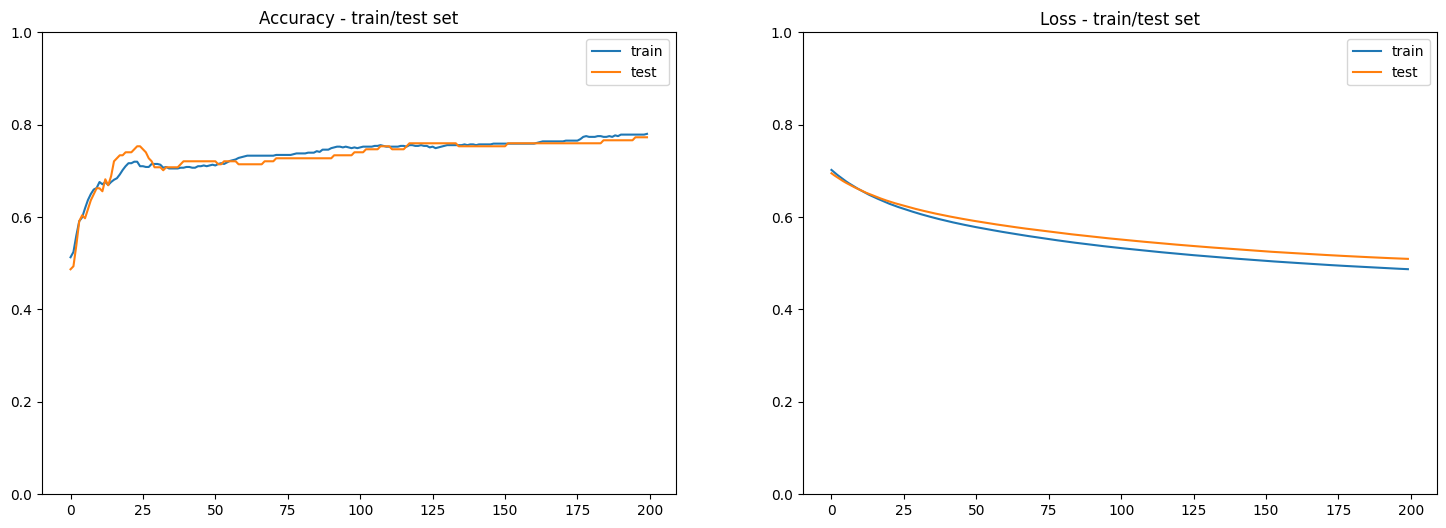

In [20]:
# plot training history

fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols=2, figsize=(18,6))

ax1.plot(history.history['accuracy'],     label='train')
ax1.plot(history.history['val_accuracy'], label='test')
ax1.set_title('Accuracy - train/test set')
ax1.set_ylim([0,1])
ax1.legend()

ax2.plot(history.history['loss'],     label='train')
ax2.plot(history.history['val_loss'], label='test')
ax2.set_title('Loss - train/test set')
ax2.set_ylim([0,1])
ax2.legend();

- Loaded data
    - Exploration of data
- prepare
    - Scaling data
    - encoding (char cols -> number)
    - split (training and testing)
- define the Keras model
    - Sequential()
    - added layers (defined the activation fn)
- define the loss function 
- define the optimizer to use (Gradient descent)
- compile the model

- Train the model with data (fit method)
- Evaluation of the model